In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing

df1 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_box_scores_2010_2024_part_1.csv')
df2 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_box_scores_2010_2024_part_2.csv')
df3 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_box_scores_2010_2024_part_3.csv')
df4 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_totals_2010_2024.csv')

df = pd.concat([df1, df2, df3], axis = 0)

df = df.drop(columns = ['jerseyNum', 'comment'], axis = 1)
df['position'] = df.groupby('personName')['position'].transform(lambda x: x.ffill().bfill())
df = df.dropna()
df['minutes'] = df['minutes'].astype(str)
df['minutes'] = df['minutes'].apply(lambda x: int(x.split(':')[0]) + (int(x.split(':')[1])/60))
selection = df4[['GAME_ID', 'WL', 'TEAM_ABBREVIATION']].copy()
selection = selection.rename({'GAME_ID' : 'gameId', 'TEAM_ABBREVIATION' : 'teamTricode'}, axis = 1)
df = pd.merge(df, selection, on = ['gameId', 'teamTricode'])
df.columns

Index(['season_year', 'game_date', 'gameId', 'matchup', 'teamId', 'teamCity',
       'teamName', 'teamTricode', 'teamSlug', 'personId', 'personName',
       'position', 'minutes', 'fieldGoalsMade', 'fieldGoalsAttempted',
       'fieldGoalsPercentage', 'threePointersMade', 'threePointersAttempted',
       'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'reboundsTotal', 'assists', 'steals', 'blocks', 'turnovers',
       'foulsPersonal', 'points', 'plusMinusPoints', 'WL'],
      dtype='object')

In [18]:
c_features = ['freeThrowsMade', 'reboundsDefensive', 'reboundsOffensive', 'blocks' ]

g_features = ['threePointersAttempted', 'assists', 'steals', 'turnovers']

f_features = ['threePointersAttempted', 'reboundsDefensive', 'steals', 'turnovers']

In [19]:
# Normalizando plusMinusPoints
min_max_scaler = preprocessing.MinMaxScaler()
scaled = min_max_scaler.fit_transform(df[['plusMinusPoints']].values)
df['plusMinusPoints'] = scaled

In [20]:
# Metricas de tempo
tempo_total = df.groupby(['gameId', 'teamId']).sum(['minutes']).reset_index().rename(columns={'minutes': 'teamMinutes'})
tempo_total = tempo_total[['gameId', 'teamId', 'teamMinutes']]
tempo_total

df = pd.merge(df, tempo_total,on=['gameId', 'teamId'], how='inner')
df['plusMinusPoints'] = df['plusMinusPoints']*df['minutes']/df['teamMinutes']
df

,season_year,game_date,gameId,matchup,teamId,teamCity,teamName,teamTricode,teamSlug,personId,...,reboundsTotal,assists,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints,WL,teamMinutes
0,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,693,...,0,0,0,0,0,0,0,0.008511,W,240.0
1,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,2566,...,2,1,0,0,0,1,5,0.066339,W,240.0
2,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,2624,...,0,0,0,0,0,1,0,0.008931,W,240.0
3,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,2734,...,0,9,0,0,2,3,31,0.098951,W,240.0
4,2010-11,2010-11-10,21000112,NJN @ CLE,1610612751,New Jersey,Nets,NJN,nets,2743,...,18,3,1,2,1,4,13,0.097466,W,240.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342429,2023-24,2024-04-14,22301186,WAS @ BOS,1610612764,Washington,Wizards,WAS,wizards,1630551,...,7,3,2,1,0,1,9,0.047758,L,215.7
342430,2023-24,2024-04-14,22301186,WAS @ BOS,1610612764,Washington,Wizards,WAS,wizards,1630557,...,3,8,1,0,0,0,8,0.049124,L,215.7
342431,2023-24,2024-04-14,22301186,WAS @ BOS,1610612764,Washington,Wizards,WAS,wizards,1630647,...,2,5,0,0,0,1,26,0.060313,L,215.7
342432,2023-24,2024-04-14,22301186,WAS @ BOS,1610612764,Washington,Wizards,WAS,wizards,1631098,...,1,2,2,0,3,4,6,0.046082,L,215.7


In [21]:
# Dummificando WL
df['W'] = df['WL'].map({'W': 1, 'L': 0})
df = df.drop(columns = ['WL'])

game_wins = df[['gameId', 'teamId', 'W']]
game_wins = game_wins.drop_duplicates(keep='first')

In [22]:
df_c = df[df['position'].str.count('C') > 0]
df_c[['gameId', 'teamId'] +c_features + ['W']]

,gameId,teamId,freeThrowsMade,reboundsDefensive,reboundsOffensive,blocks,W
7,21000112,1610612751,2,4,2,0,1
15,21000020,1610612751,0,0,1,1,1
18,21000020,1610612751,13,5,1,1,1
29,21000040,1610612751,4,2,3,0,0
37,21000005,1610612751,0,2,1,1,1
...,...,...,...,...,...,...,...
342393,22301152,1610612764,2,8,1,3,0
342407,22301117,1610612764,3,6,1,1,0
342416,22301137,1610612764,2,6,3,3,0
342425,22301172,1610612764,7,1,0,1,0


In [23]:
df_c[c_features] = min_max_scaler.fit_transform(df_c[c_features].values)

df_c['individual_position_score'] = df_c[c_features].mean(axis=1)

df_c = df_c[['gameId', 'teamId', 'individual_position_score', 'W']]

df_c

C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\882012571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c[c_features] = min_max_scaler.fit_transform(df_c[c_features].values)
C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\882012571.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c['individual_position_score'] = df_c[c_features].mean(axis=1)


,gameId,teamId,individual_position_score,W
7,21000112,1610612751,0.091256,1
15,21000020,1610612751,0.034722,1
18,21000020,1610612751,0.219070,1
29,21000040,1610612751,0.103406,0
37,21000005,1610612751,0.056461,1
...,...,...,...,...
342393,22301152,1610612764,0.183345,0
342407,22301117,1610612764,0.129940,0
342416,22301137,1610612764,0.189384,0
342425,22301172,1610612764,0.101703,0


In [24]:
df_g = df[df['position'].str.count('G') > 0]

df_g[g_features] = min_max_scaler.fit_transform(df_g[g_features].values)

df_g['individual_position_score'] = df_g[g_features].mean(axis=1)

df_g = df_g[['gameId', 'teamId', 'individual_position_score', 'W']]

df_g

C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\4021576207.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g[g_features] = min_max_scaler.fit_transform(df_g[g_features].values)
C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\4021576207.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g['individual_position_score'] = df_g[g_features].mean(axis=1)


,gameId,teamId,individual_position_score,W
3,21000112,1610612751,0.173333,1
6,21000112,1610612751,0.214167,1
8,21000112,1610612751,0.124167,1
13,21000020,1610612751,0.229167,1
16,21000020,1610612751,0.000000,1
...,...,...,...,...
342418,22301172,1610612764,0.181250,0
342421,22301172,1610612764,0.237083,0
342426,22301186,1610612764,0.092917,0
342427,22301186,1610612764,0.220000,0


In [25]:
df_f = df[df['position'].str.count('F') > 0]

df_f[f_features] = min_max_scaler.fit_transform(df_f[f_features].values)

df_f['individual_position_score'] = df_f[f_features].mean(axis=1)

df_f = df_f[['gameId', 'teamId', 'individual_position_score', 'W']]

df_f

C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\2563830870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f[f_features] = min_max_scaler.fit_transform(df_f[f_features].values)
C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\2563830870.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['individual_position_score'] = df_f[f_features].mean(axis=1)


,gameId,teamId,individual_position_score,W
0,21000112,1610612751,0.000000,1
1,21000112,1610612751,0.035714,1
2,21000112,1610612751,0.000000,1
4,21000112,1610612751,0.188690,1
5,21000112,1610612751,0.036905,1
...,...,...,...,...
342424,22301172,1610612764,0.260119,0
342429,22301186,1610612764,0.145238,0
342431,22301186,1610612764,0.083333,0
342432,22301186,1610612764,0.124405,0


In [26]:
df_c = df_c.groupby(['gameId', 'teamId'])['individual_position_score'].sum().reset_index()
df_c.rename(columns={'individual_position_score': 'c_score'}, inplace=True)

df_f = df_f.groupby(['gameId', 'teamId'])['individual_position_score'].sum().reset_index()
df_f.rename(columns={'individual_position_score': 'f_score'}, inplace=True)

df_g = df_g.groupby(['gameId', 'teamId'])['individual_position_score'].sum().reset_index()
df_g.rename(columns={'individual_position_score': 'g_score'}, inplace=True)

df_scores = pd.merge(df_c, df_f, on=['gameId', 'teamId'], how='inner')
df_scores = pd.merge(df_scores, df_g, on=['gameId', 'teamId'], how='inner')
df_scores = pd.merge(df_scores, game_wins, on=['gameId', 'teamId'], how='inner')

min_max_scaler = preprocessing.MinMaxScaler()
scaled = min_max_scaler.fit_transform(df_scores[['c_score', 'f_score', 'g_score']].values)

df_scores[['c_score', 'f_score', 'g_score']] = scaled

df_scores

,gameId,teamId,c_score,f_score,g_score,W
0,21000001,1610612738,0.312075,0.526800,0.366162,1
1,21000001,1610612748,0.261511,0.400108,0.393519,0
2,21000002,1610612756,0.156658,0.274499,0.412458,0
3,21000002,1610612757,0.262861,0.428803,0.375000,1
4,21000003,1610612745,0.594449,0.459123,0.276515,0
...,...,...,...,...,...,...
33311,22301228,1610612758,0.354322,0.291825,0.441919,1
33312,22301229,1610612749,0.391565,0.335138,0.302609,0
33313,22301229,1610612754,0.465691,0.224147,0.566077,1
33314,22301230,1610612740,0.238273,0.295073,0.345960,0


In [27]:
# Regressão logistica

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df_scores[['c_score', 'f_score', 'g_score']]
y = df_scores['W']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1933 1367]
 [1476 1888]]
              precision    recall  f1-score   support

           0       0.57      0.59      0.58      3300
           1       0.58      0.56      0.57      3364

    accuracy                           0.57      6664
   macro avg       0.57      0.57      0.57      6664
weighted avg       0.57      0.57      0.57      6664



In [28]:
import pandas as pd

# Pegue os coeficientes do modelo
coef = model.coef_[0]

# Relacione com os nomes das variáveis
features = ['c_score', 'f_score', 'g_score']
coef_df = pd.DataFrame({'feature': features, 'coeficiente': coef})
coef_df['influencia'] = coef_df['coeficiente'].abs()
coef_df = coef_df.sort_values('influencia', ascending=False)

print(coef_df)

   feature  coeficiente  influencia
0  c_score     2.601402    2.601402
1  f_score     2.325294    2.325294
2  g_score     1.574413    1.574413


C:\Users\Raposo\AppData\Local\Temp\ipykernel_21904\3896065753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coeficiente', y='feature', palette='coolwarm')


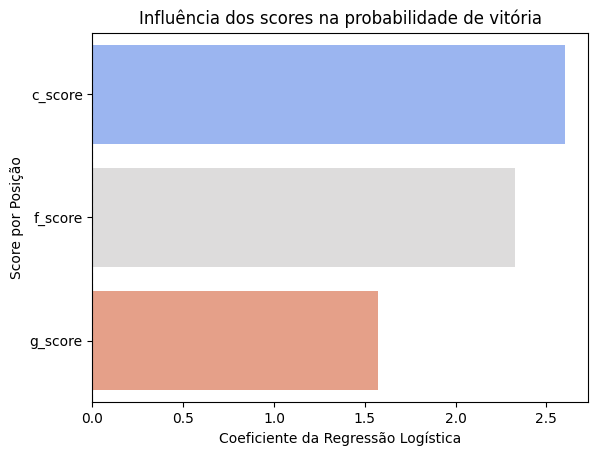

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=coef_df, x='coeficiente', y='feature', palette='coolwarm')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Influência dos scores na probabilidade de vitória')
plt.xlabel('Coeficiente da Regressão Logística')
plt.ylabel('Score por Posição')
plt.show()

In [31]:
import statsmodels.api as sm

# Adiciona constante (intercepto)
X_sm = sm.add_constant(X)
X_train_sm, X_test_sm, y_train, y_test = train_test_split(X_sm, y, test_size=0.2, random_state=42)

# Ajusta o modelo
model_sm = sm.Logit(y_train, X_train_sm).fit()

# Mostra o resumo com coeficientes, erros, z-estatística, p-valor
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.671772
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      W   No. Observations:                26652
Model:                          Logit   Df Residuals:                    26648
Method:                           MLE   Df Model:                            3
Date:                Thu, 26 Jun 2025   Pseudo R-squ.:                 0.03083
Time:                        21:23:26   Log-Likelihood:                -17904.
converged:                       True   LL-Null:                       -18474.
Covariance Type:            nonrobust   LLR p-value:                1.128e-246
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3819      0.078    -30.613      0.000      -2.534      -2.229
c_score        2.6346      0.